In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV


# Preparing dataset

In [14]:
#Pre-processes dataset and splits it into train and test-set in the specified ratio
def preprocessing(df, y_label, frac):

    #Drop rows with missing values (if any)
    df = df.dropna()

    #split into train and test set
    df_train = df.sample(frac=frac, axis=0)
    df_test = df.drop(df_train.index)

    #Choose target feature
    y_train = df_train[y_label].to_numpy()
    X_train = df_train.drop(columns=y_label).to_numpy()

    y_test = df_test[y_label].to_numpy()
    X_test = df_test.drop(columns=y_label).to_numpy()

    return X_train, y_train, X_test, y_test


In [15]:
df_iris = pd.read_csv('iris/iris.data', sep=',', header=None)

#since the class labels is in the 4th column we select it as the target vector
Xtrain, ytrain, Xtest, ytest = preprocessing(df_iris, 4, 0.7)



# K-NN Implementation

In [16]:
def euclidean_distance(X_1, X_2):
    """Compute pairwise Euclidean distances between two data points.

    Parameters
    ----------
    X_1 : array, shape (N, 4)
        First set of data points.
    X_2 : array, shape (M, 4)
        Second set of data points.

    Returns
    -------
    distance : float array, shape (N, M)
        Pairwise Euclidean distances between x1 and x2.
    """

    #Broadcasts into shape (N, M, 4) during subtraction
    return np.sqrt(np.sum((X_1[:, None] - X_2[None])**2, -1))


def get_knn(Xtrain, ytrain, Xtest, k):

    """Get the labels of the k nearest neighbors of the datapoints x_new.

    Parameters
    ----------
    X_train : array, shape (N_train, 4)
        Training features.
    y_train : array, shape (N_train)
        Training labels.
    X_test : array, shape (M, 4)
        Data points for which the neighbors have to be found.
    k : int
        Number of neighbors to return.

    Returns
    -------
    neighbors_labels : array, shape (M, k)
        Array containing the labels of the k nearest neighbors.
    """

    distances = euclidean_distance(Xtest, Xtrain)
    nearest = np.argsort(distances, axis=1)[:, :k]
    return ytrain[nearest]

def predict(neighbours_labels):

    majority_labels = []
    for row in neighbours_labels:
        labels, counts = np.unique(row, return_counts=True)
        majority_labels.append(labels[np.argmax(counts)])

    return np.array(majority_labels)

def get_accuracy(y_pred, y_test):

    return np.mean(y_test == y_pred)

#Finally we implement a function that calculates the prediction accuracy for a test set
def calculate_knn_accuracy(Xtrain, ytrain, Xtest, ytest, k):


    neighbors_labels = get_knn(Xtrain, ytrain, Xtest, k)
    y_pred = predict(neighbors_labels)
    return get_accuracy(y_pred, ytest)


The quality criterion chosen here is a one-loss function.

# Optimize and Compare KNN Algorithm

To find the best K, we use grid search with cross validation with one-loss function defined above as the quality criterion

In [17]:
def get_best_k_using_cv(X, y, max_k, num_folds=10):
    """
    Perform k-fold cross-validation to find the best k for k-NN.

    Parameters
    ----------
    X : array, shape (N, D)
        Feature matrix.
    y : array, shape (N,)
        Labels.
    max_k : int
        Maximum k to be evaluated.
    num_folds : int
        Number of folds for cross-validation.

    Returns
    -------
    best_k : int
        The value of k with the highest average validation accuracy.
    avg_accuracies : List
        Average accuracy for k's after cross-validation.
    """

    kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)
    avg_accuracies = []

    for k in range(1, max_k + 1):
        accuracies = []

        for train_indices, val_indices in kf.split(X):
            Xtrain, Xval = X[train_indices], X[val_indices]
            ytrain, yval = y[train_indices], y[val_indices]

            acc = calculate_knn_accuracy(Xtrain, ytrain, Xval, yval, k)
            accuracies.append(acc)

        avg_accuracies.append(np.mean(accuracies))

    best_k = np.argmax(avg_accuracies)+1

    return best_k, avg_accuracies




Optimal k after Cross Validation:11
Accuracy on test set:1.0


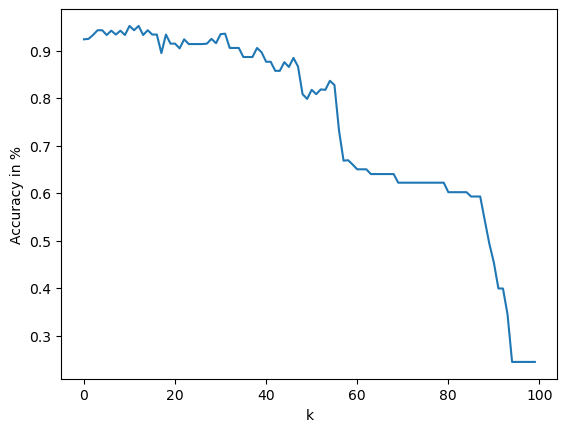

In [18]:
X = np.concatenate((Xtrain, Xtest), axis=0)
y = np.concatenate((ytrain, ytest), axis=0)

#Get the k with the best accuracy using the training set
best_k, avg_accuracies = get_best_k_using_cv(Xtrain, ytrain, 100)

print(f"Optimal k after Cross Validation:{best_k}")

#Calculate accuracy on test set using optimal k
test_acc = calculate_knn_accuracy(Xtrain, ytrain, Xtest, ytest, best_k)
print(f"Accuracy on test set:{test_acc}")

#Plotting average accuracies calculated during cv for each k
plt.plot(avg_accuracies)
plt.xlabel("k")
plt.ylabel("Accuracy in %")
plt.show()

Comparing K-NN with Tree-based methods from sklearn and computing optimal Hyperparameters using Grid-search and CV

In [19]:
#k-NN
knn_params = {'n_neighbors': np.arange(1, 40, 1), 'weights': ['uniform', 'distance'],'p': [1,2]}
knn_clf = GridSearchCV( KNeighborsClassifier(), knn_params, scoring='accuracy')
knn_clf.fit(Xtrain, ytrain)

best_knn_params = knn_clf.best_params_
print(f"Optimal parameters for kNN:{best_knn_params}")

test_acc = knn_clf.best_estimator_.score(Xtest, ytest)
print(f"Accuracy of kNN on test set:{test_acc}")


Optimal parameters for kNN:{'n_neighbors': 13, 'p': 1, 'weights': 'uniform'}
Accuracy of kNN on test set:1.0


/home/ryan/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [20]:
#dt
dt_params = {'criterion': ['gini', 'entropy', 'log_loss'], 'max_depth': np.arange(1, 50, 1)}
dt_clf = GridSearchCV( DecisionTreeClassifier(), dt_params, scoring='accuracy')
dt_clf.fit(Xtrain, ytrain)

best_dt_params = dt_clf.best_params_
print(f"Optimal parameters for Decision Trees:{best_dt_params}")

test_acc = dt_clf.best_estimator_.score(Xtest, ytest)
print(f"Accuracy of Decision Trees on test set:{test_acc}")



Optimal parameters for Decision Trees:{'criterion': 'gini', 'max_depth': 3}
Accuracy of Decision Trees on test set:1.0


/home/ryan/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Comparing the dt and knn implementations from sklearn and our own knn implementation, we see that optimal accuracy on the test set can be achieved for all models by using cross-validation and grid seacrh to find the optimal parameters.

# Recommender system using cosine similarity measures

In [21]:
#Rating prediction dataset (rating scale 1-5). http://grouplens.org/datasets/movielens/100k/

ratings_df = pd.read_csv('ml-1m/ml-1m/ratings.dat', sep='::',  header=None, encoding='latin-1', engine='python')
movies_df = pd.read_csv('ml-1m/ml-1m/movies.dat', sep='::', header=None, encoding='latin-1', engine='python')
users_df = pd.read_csv('ml-1m/ml-1m/users.dat', sep='::', header=None, encoding='latin-1', engine='python')


users_df[1] = users_df[1].map({'M': 1, 'F': 0})
#Drop the column containing zip-code
users_df = users_df.drop(columns=4, axis=1)

#Split and preprocess the rating dataset
Xtrain_rating, ytrain_rating, Xtest_rating, ytest_rating = preprocessing(ratings_df, 2, 0.7)


#user_indices = np.unique(Xtest_rating[:, 0] - 1)
users = users_df.to_numpy()
#user_test = users[user_indices]
#user_train = users[np.setdiff1d(np.arange(users.shape[0]), user_indices)]


#movies_indices = np.unique(Xtest_rating[:, 1] - 1)
movies = movies_df.to_numpy()
#movies_test = movies[movies_indices]
#movies_train = movies[np.setdiff1d(np.arange(movies.shape[0]), movies_indices)]





In [22]:
def cosine_similarity(vec, mat):
    """
    Compute cosine similarity between a single vector and each row in a matrix.

    Parameters:
    -----------
    vec : np.ndarray, shape (D,)
        The input vector.
    mat : np.ndarray, shape (N, D)
        The matrix.

    Returns:
    --------
    similarities : np.ndarray, shape (N,)
        Cosine similarity between `vec` and each row in `mat`.
    """
    vec_norm = vec / (np.linalg.norm(vec) + 1e-10)
    mat_norm = mat / (np.linalg.norm(mat, axis=1, keepdims=True) + 1e-10)
    return mat_norm @ vec_norm



def predict_user_knn_cos(Xtrain, ytrain, Xtest, ytest, users, k):

    y_pred = []

    #Global mean as fallback if no ratings where found for a particular movie by other users
    fallback_rating = np.mean(ytest)

    #we go through each line in the rating test dataset
    for user_id, movie_id, _ in Xtest:

        # Find all users who rated this movie in the rating train dataset
        mask = Xtrain[:, 1] == movie_id
        relevant_user_ids = Xtrain[mask][:,0]
        relevant_ratings = ytrain[mask]

        #No users found
        if len(relevant_user_ids) == 0:
            y_pred.append(fallback_rating)
            continue


        #Get user descriptions from users
        test_user = users[user_id - 1] #(M,)
        neighbors = users[relevant_user_ids - 1] #(N,M)


        #Compute similarity to test user
        sims = cosine_similarity(test_user, neighbors)

        #Select top-k neighbors
        top_k_idx = np.argsort(sims)[-k:][::-1]



        top_k_ratings = relevant_ratings[top_k_idx]

        pred = np.mean(top_k_ratings)

        y_pred.append(pred)

    return np.array(y_pred)




We will predict the rating given by a user for a particular movie by averaging over all the ratings given by k-most similar users for the same movie

In [23]:
from concurrent.futures import ProcessPoolExecutor


def evaluate_rmse_k(args):
    Xtrain, ytrain, Xtest, ytest, users, k = args
    y_pred = predict_user_knn_cos(Xtrain, ytrain, Xtest, ytest, users, k)
    rmse = np.sqrt(np.mean((ytest - y_pred) ** 2))
    return rmse, k

k_values = [50,200,300,500,800,1000,2000]

# Create argument tuples for each k
args_list = [(Xtrain_rating, ytrain_rating, Xtest_rating, ytest_rating, users, k) for k in k_values]

results = {}

with ProcessPoolExecutor() as executor:
    for rmse, k in executor.map(evaluate_rmse_k, args_list):
        results[k] = rmse
        print(f"k={k}, RMSE={rmse:.4f}")

best_k = min(results, key=results.get)
print(f"Best k: {best_k} with RMSE={results[best_k]:.4f}")


k=50, RMSE=0.9863
k=200, RMSE=0.9811
k=300, RMSE=0.9808
k=500, RMSE=0.9807
k=800, RMSE=0.9808
k=1000, RMSE=0.9809
k=2000, RMSE=0.9809
Best k: 500 with RMSE=0.9807
